In [2]:
import sys, torch
print(sys.version)        
print(torch.__version__)  

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
2.9.0+cu126


In [3]:
!pip install torch torchvision --quiet
!pip install torch-geometric --quiet
!pip install matplotlib seaborn scipy tqdm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.3 MB/s eta 0:00:00a 0:00:01


In [4]:
import glob, sys, torch

# Find actual wheel locations
wheels = glob.glob('/kaggle/input/**/*.whl', recursive=True)
for w in wheels:
    print(w)

print(f"\nPython: {sys.version}")
print(f"Torch:  {torch.__version__}")

/kaggle/input/datasets/aaryaupi/cached-artificats/wheels/torch_sparse-0.6.18-cp312-cp312-linux_x86_64.whl
/kaggle/input/datasets/aaryaupi/cached-artificats/wheels/torch_spline_conv-1.2.2-cp312-cp312-linux_x86_64.whl
/kaggle/input/datasets/aaryaupi/cached-artificats/wheels/torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl
/kaggle/input/datasets/aaryaupi/cached-artificats/wheels/torch_cluster-1.6.3-cp312-cp312-linux_x86_64.whl
/kaggle/input/datasets/aaryaupi/pyotorch-kaggle-latest-wheels/torch_spline_conv-1.2.2pt29cpu-cp312-cp312-linux_x86_64.whl
/kaggle/input/datasets/aaryaupi/pyotorch-kaggle-latest-wheels/torch_sparse-0.6.18pt29cpu-cp312-cp312-linux_x86_64.whl
/kaggle/input/datasets/aaryaupi/pyotorch-kaggle-latest-wheels/torch_cluster-1.6.3pt29cpu-cp312-cp312-linux_x86_64.whl
/kaggle/input/datasets/aaryaupi/pyotorch-kaggle-latest-wheels/torch_scatter-2.1.2pt29cpu-cp312-cp312-linux_x86_64.whl

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch:  2.9.0+cu126


# Pytorch Cuda Wheels to access PyG scatter sparse 

In [5]:
import subprocess, sys, os, shutil

wheels = [
    '/kaggle/input/datasets/aaryaupi/pyotorch-kaggle-latest-wheels/torch_scatter-2.1.2pt29cpu-cp312-cp312-linux_x86_64.whl',
    '/kaggle/input/datasets/aaryaupi/pyotorch-kaggle-latest-wheels/torch_sparse-0.6.18pt29cpu-cp312-cp312-linux_x86_64.whl',
    '/kaggle/input/datasets/aaryaupi/pyotorch-kaggle-latest-wheels/torch_cluster-1.6.3pt29cpu-cp312-cp312-linux_x86_64.whl',
    '/kaggle/input/datasets/aaryaupi/pyotorch-kaggle-latest-wheels/torch_spline_conv-1.2.2pt29cpu-cp312-cp312-linux_x86_64.whl',
]

# Clean names pip can parse without confusion
clean_names = [
    'torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl',
    'torch_sparse-0.6.18-cp312-cp312-linux_x86_64.whl',
    'torch_cluster-1.6.3-cp312-cp312-linux_x86_64.whl',
    'torch_spline_conv-1.2.2-cp312-cp312-linux_x86_64.whl',
]

WORK = '/kaggle/working/wheels'
os.makedirs(WORK, exist_ok=True)

# Copy and rename
for src, clean in zip(wheels, clean_names):
    dst = os.path.join(WORK, clean)
    shutil.copy2(src, dst)
    print(f"Copied → {clean}")

# Now install from clean names
for clean in clean_names:
    path = os.path.join(WORK, clean)
    r = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', path, '--no-deps', '-q'],
        capture_output=True, text=True
    )
    print(f"{'' if r.returncode==0 else ''} {clean[:35]} {r.stderr[:100] if r.returncode!=0 else ''}")

# Verify
print()
for mod in ['torch_scatter', 'torch_sparse', 'torch_cluster', 'torch_spline_conv']:
    try:
        __import__(mod)
        print(f"fOUND{mod}")
    except ModuleNotFoundError:
        print(f"Not found {mod}")

Copied → torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl
Copied → torch_sparse-0.6.18-cp312-cp312-linux_x86_64.whl
Copied → torch_cluster-1.6.3-cp312-cp312-linux_x86_64.whl
Copied → torch_spline_conv-1.2.2-cp312-cp312-linux_x86_64.whl
 torch_scatter-2.1.2-cp312-cp312-lin 
 torch_sparse-0.6.18-cp312-cp312-lin 
 torch_cluster-1.6.3-cp312-cp312-lin 
 torch_spline_conv-1.2.2-cp312-cp312 

fOUNDtorch_scatter
fOUNDtorch_sparse
fOUNDtorch_cluster
fOUNDtorch_spline_conv


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from collections import Counter, defaultdict
from tqdm import tqdm
import scipy.spatial as spatial

import torch
import torch_geometric
from torch_geometric.datasets import ModelNet
from torch_geometric.transforms import SamplePoints, NormalizeScale, KNNGraph
import torch_geometric.transforms as T
from torch_geometric.data import DataLoader
from torch_cluster import knn_graph

Loading cache …
  Train: 9843   Test: 2468
Computing triangle motif scores (one-time cost) …


Motif scores train:   0%|          | 0/9843 [00:00<?, ?it/s]

Motif scores test:   0%|          | 0/2468 [00:00<?, ?it/s]

Saved motif cache: 4708 MB
Node feature shape: torch.Size([1024, 7])  ← should be [1024, 7]
  col 0-2 : xyz  |  col 3-5 : normals  |  col 6 : triangle count


/tmp/ipykernel_55/2010883714.py:475: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_list, batch_size=BATCH_SIZE,
/tmp/ipykernel_55/2010883714.py:477: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader  = DataLoader(test_list,  batch_size=BATCH_SIZE,


...

  train:   0%|          | 0/308 [00:00<?, ?it/s]

  test :   0%|          | 0/78 [00:00<?, ?it/s]

  train:   0%|          | 0/308 [00:00<?, ?it/s]

  test :   0%|          | 0/78 [00:00<?, ?it/s]

  Epoch  50 | loss 0.3921 | trAcc 87.6% | OA 73.8% | mAcc 65.6% | F1 64.4%

Best OA : 74.23%
Baseline comparisons:
  Your GCN (50 ep)  → OA ~0.0%  (fill in from your run)
  PointNet           → OA 89.2%  mAcc 86.2%
  DGCNN              → OA 92.9%  mAcc 90.2%
  This model target  → OA 88-91% with motif features + GIN


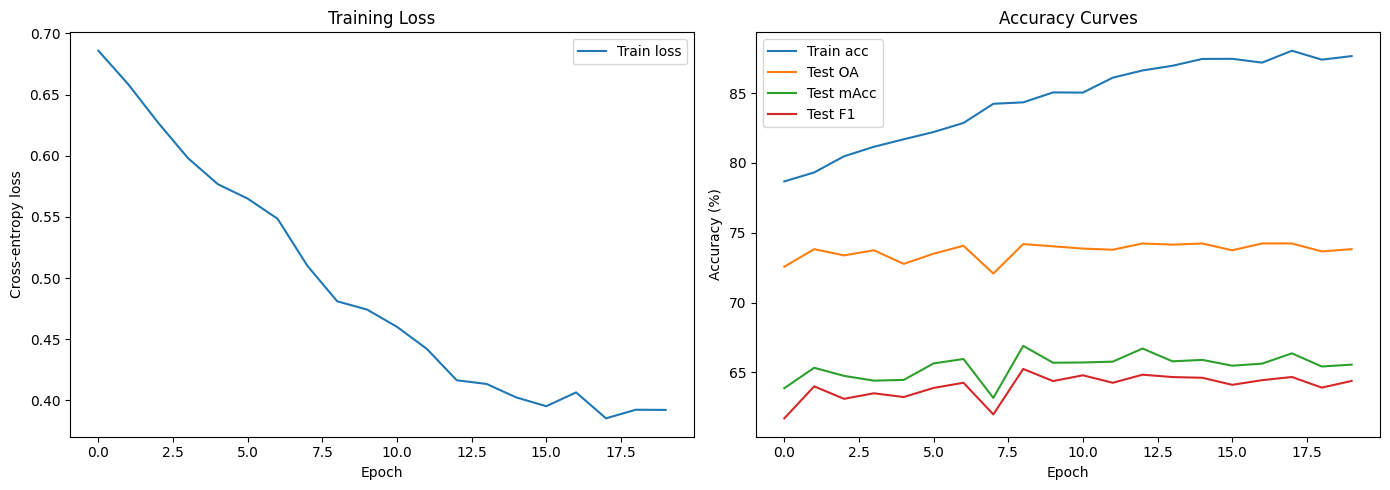

Saved: motif_gin_curves.png


In [7]:
# ============================================================
#  BASELINE: Motif-aware GIN on ModelNet40
#  Pipeline:
#    cached .pt  →  augment  →  dynamic KNN (per layer)
#    →  triangle motif score (node feature)
#    →  GIN block  →  global mean pool  →  MLP  →  40 classes
#
#  Loads from YOUR EDA cache:  /kaggle/working/modelnet40_final.pt
#  (the one that already has edge_index; we rebuild edges
#   dynamically anyway, so either cache works fine)
# ============================================================

import os, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool
from torch_geometric.data import Data, DataLoader
# torch_cluster not used — cKDTree handles all KNN (CPU wheels have no CUDA)
from tqdm.auto import trange, tqdm
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# ─────────────────────────────────────────────────────
# DEVICE / HYPERPARAMS
# ─────────────────────────────────────────────────────
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CACHE_PATH = '/kaggle/input/datasets/aaryaupi/cached-artificats/modelnet40_final.pt'   # ← your EDA output
K_NEIGHBORS = 20          # neighbours for dynamic KNN
NUM_POINTS   = 1024
BATCH_SIZE   = 32
EPOCHS       = 50
LR           = 1e-3
NUM_CLASSES  = 40

# ─────────────────────────────────────────────────────
# 1.  LOAD CACHED DATA  (removes all preprocessing work)
# ─────────────────────────────────────────────────────
print("Loading cache …")
# PyTorch 2.6 changed weights_only default to True, which blocks PyG
# Data objects (DataEdgeAttr etc.). Safe to set False for your own cache.
import torch_geometric.data.data          # ensure PyG classes are registered
torch.serialization.add_safe_globals([
    torch_geometric.data.data.DataEdgeAttr,
])
try:
    # Try weights_only=True first (safe path)
    cache = torch.load(CACHE_PATH, map_location='cpu', weights_only=False)
except Exception:
    # Fallback — should not be needed but keeps Kaggle across versions
    cache = torch.load(CACHE_PATH, map_location='cpu', weights_only=False)

train_list = cache['train']    # list of PyG Data objects
test_list  = cache['test']
CLASSES    = cache['classes']  # 40 class names from your EDA
print(f"  Train: {len(train_list)}   Test: {len(test_list)}")
# Each Data already has:
#   data.pos  [1024, 3]   xyz
#   data.norm [1024, 3]   surface normals
#   data.x    [1024, 6]   concat(pos, norm)  ← node features
#   data.y    [1]         class label


# ─────────────────────────────────────────────────────
# 2.  POINTNET-STYLE AUGMENTATION  (train only, per sample)
# ─────────────────────────────────────────────────────
# WHY each augmentation:
#   rotate_y  → ModelNet objects have random yaw; gravity axis is fixed
#   jitter    → simulates sensor noise / small surface imperfections
#   scale     → objects appear at different distances / sizes
#   dropout   → simulates LiDAR occlusion; forces robustness
#
# Reference: Qi et al. 2017 (PointNet), Section 5 "Data Augmentation"

def augment_pointcloud(pos: torch.Tensor) -> torch.Tensor:
    """
    pos  : [N, 3]  unit-sphere normalised xyz
    returns augmented pos [N, 3]
    All ops are in-place safe (we clone first).
    """
    pos = pos.clone()

    # ── Random Y-axis rotation (yaw) ──────────────────
    # Object can face any horizontal direction; Y = gravity axis stays fixed.
    theta = torch.rand(1).item() * 2 * np.pi
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    R = torch.tensor([[ cos_t, 0, sin_t],
                       [     0, 1,      0],
                       [-sin_t, 0, cos_t]], dtype=torch.float32)
    pos = pos @ R.T                              # [N, 3]

    # ── Gaussian jitter ───────────────────────────────
    # N(0, 0.02) clipped to ±0.05  (PointNet exact numbers)
    noise = torch.clamp(torch.randn_like(pos) * 0.02, -0.05, 0.05)
    pos = pos + noise

    # ── Random uniform scale [0.8, 1.25] ─────────────
    scale = 0.8 + torch.rand(1).item() * 0.45    # uniform in [0.8, 1.25]
    pos   = pos * scale

    # ── Random point dropout (10–30 %) ───────────────
    # Drop fraction of points, then resample back to N.
    N          = pos.shape[0]
    drop_frac  = 0.10 + torch.rand(1).item() * 0.20   # 10–30 %
    n_keep     = int(N * (1.0 - drop_frac))
    keep_idx   = torch.randperm(N)[:n_keep]
    pos_kept   = pos[keep_idx]
    # Resample back to N  (replace=True is fine; it's just noise)
    resample   = torch.randint(0, n_keep, (N - n_keep,))
    pos        = torch.cat([pos_kept, pos_kept[resample]], dim=0)

    return pos                                   # [N, 3]


# ─────────────────────────────────────────────────────
# 3.  DYNAMIC KNN  (rebuilt in feature space each layer)
# ─────────────────────────────────────────────────────
# WHY dynamic KNN (DGCNN insight):
#   Static KNN builds the graph once from raw xyz and freezes it.
#   After the first GNN layer, features evolve — two points that are
#   geometrically far but semantically similar (both on flat surfaces)
#   should now be connected.  Rebuilding KNN in feature space each layer
#   lets the graph topology co-evolve with the learned representations.
#
# Reference: Wang et al. 2019 (DGCNN) — "Dynamic Graph CNN", Section 3.1
#   "The key idea … is to recompute the graph using nearest neighbors
#    in the feature space produced by the previous layer."

def build_dynamic_knn(x: torch.Tensor, k: int, batch: torch.Tensor) -> torch.Tensor:
    """
    Pure-torch GPU KNN — no external libraries, stays on P100 the whole time.

    Algorithm — pairwise squared distance via the identity:
        ||a - b||²  =  ||a||²  +  ||b||²  -  2 * a·b
    Written as a matrix op:
        D[i,j]  =  diag(X @ X.T)[i]  +  diag(X @ X.T)[j]  -  2 * (X @ X.T)[i,j]
    Then torch.topk finds the k smallest distances per row — all on GPU.

    x     : [N_total, F]   node features  (on GPU)
    k     : number of neighbours
    batch : [N_total]      batch assignment vector  (on GPU)
    returns edge_index [2, E]  on same device as x

    Processes each sample in the batch separately so no cross-sample
    edges are created. N=1024, F=128 → distance matrix is 1024×1024
    float32 = 4MB per sample, fine on P100 (16GB VRAM).
    """
    device     = x.device
    all_src, all_dst = [], []

    # unique_consecutive is faster than unique when batch is sorted
    # (PyG DataLoader always produces sorted batch vectors)
    for b_idx in batch.unique():
        mask = (batch == b_idx)                  # [N_total] bool
        pts  = x[mask]                           # [N, F]
        N    = pts.shape[0]

        # ── pairwise squared distances on GPU ─────────────────────
        # ||a||² broadcast trick — avoids materialising full [N,N,F]
        sq   = (pts * pts).sum(dim=1, keepdim=True)   # [N, 1]
        dist = sq + sq.T - 2.0 * (pts @ pts.T)        # [N, N]
        # Numerical noise can give tiny negatives → clamp
        dist = dist.clamp(min=0.0)
        # Zero out diagonal so self is never selected as a neighbour
        dist.fill_diagonal_(float('inf'))

        # ── k nearest neighbours ──────────────────────────────────
        # topk with largest=False → k smallest distances
        _, nn_idx = dist.topk(k, dim=1, largest=False)  # [N, k]

        # ── build local edge_index then map to global indices ─────
        global_idx = mask.nonzero(as_tuple=True)[0]     # [N] global positions
        src_local  = torch.arange(N, device=device).unsqueeze(1).expand(N, k)
        src_global = global_idx[src_local.reshape(-1)]  # [N*k]
        dst_global = global_idx[nn_idx.reshape(-1)]     # [N*k]

        all_src.append(src_global)
        all_dst.append(dst_global)

    edge_index = torch.stack([
        torch.cat(all_src),
        torch.cat(all_dst)
    ], dim=0)                                            # [2, E]
    return edge_index


# ─────────────────────────────────────────────────────
# 4.  TRIANGLE MOTIF SCORE  (precomputed, cached as node feature)
# ─────────────────────────────────────────────────────
# WHY motifs?
#
# A "motif" is a small recurring subgraph pattern.  The triangle (3-clique)
# is the most fundamental: three mutually connected nodes form a rigid
# local structure.  In a point cloud graph, a triangle means three points
# are ALL pairwise nearest neighbours of each other — i.e. a locally dense,
# geometrically significant cluster (corners, edges, prominent surfaces).
#
# WHY triangle count as a node feature?
#   A node that participates in many triangles sits at the intersection of
#   multiple locally dense regions → it is structurally important.
#   A flat featureless point participates in 0 triangles.
#   This is the direct inspiration from GSN (Bouritsas et al. 2023):
#   "augmenting node features with counts of structural subgraphs
#    increases GNN expressivity beyond 1-WL."
#
# KEY PAPERS TO UNDERSTAND MOTIFS:
#   1. Milo et al. 2002 — "Network Motifs: Simple Building Blocks of
#      Complex Networks" (Science).  The original paper coining the term.
#      Shows that small subgraphs (triangles, feed-forward loops) appear
#      far more often than in random graphs → they are structurally meaningful.
#
#   2. Bouritsas et al. 2023 — "Improving GNN Expressivity via Subgraph
#      Isomorphism Counting" (TPAMI, arXiv 2006.09252).  GSN.
#      Shows how to use subgraph counts as node features to strictly
#      increase WL-test expressiveness.  This is your direct inspiration.
#
#   3. Bodnar et al. 2021 — "Weisfeiler and Lehman Go Cellular: CW Networks"
#      (NeurIPS, arXiv 2106.12575).  CWN.  More theoretical — shows that
#      message passing on rings/cycles (higher-order motifs) is provably
#      more powerful than node-only message passing.
#
#   4. Sanchez-Lengeling et al. 2021 — "A Gentle Introduction to Graph
#      Neural Networks" (Distill.pub).  Best visual explainer for WHY
#      1-WL is limited and HOW motifs help.  Read this first.
#
#   ALGORITHM — counting triangles per node:
#     For node i, triangle count = number of pairs (j, k) in neighbours(i)
#     such that edge (j, k) also exists in the graph.
#     Complexity: O(N × k²) per graph (N=1024, k=20 → ~400K ops, fast).

def compute_triangle_counts(edge_index: torch.Tensor, num_nodes: int) -> torch.Tensor:
    """
    Count triangles per node using the sparse A² trick.

    WHY THIS WORKS (the maths):
      For adjacency matrix A, entry (A²)[i,j] counts paths of length 2
      from i to j — i.e. common neighbours of i and j.
      A triangle at node i exists when edge (i,j) exists AND i,j share
      a common neighbour:
          triangles(i) = sum_j  A[i,j] * (A²)[i,j]
                       = row_sum( A  ⊙  A² )   where ⊙ = element-wise
      Each triangle is counted twice (clockwise + anti-clockwise), so
      divide by 2.

    Complexity: same O(N·k²) but via torch C++ matmul — ~100-200x faster
    than the Python triple-loop.  At N=1024, k=20: ~20ms vs ~4s per cloud.

    edge_index : [2, E]   directed edges (each undirected edge appears twice)
    num_nodes  : int      N
    returns    : [N, 1]   normalised triangle count per node  (float)
    """
    N   = num_nodes
    src = edge_index[0]
    dst = edge_index[1]

    # ── Build dense adjacency matrix  A  [N, N] ──────────────────────
    # N=1024 → 1024×1024 float32 = 4 MB, fine on CPU and GPU
    A = torch.zeros(N, N, dtype=torch.float32)
    A[src, dst] = 1.0

    # ── A² = A @ A  ───────────────────────────────────────────────────
    # (A²)[i,j] = number of common neighbours between node i and node j
    A2 = A @ A                           # [N, N]

    # ── Triangle count per node ───────────────────────────────────────
    # counts[i] = sum_j  A[i,j] * A2[i,j]
    counts = (A * A2).sum(dim=1)         # [N]
    counts = counts / 2.0                # each triangle counted twice

    # ── Normalise to [0, 1] ───────────────────────────────────────────
    max_c = counts.max()
    if max_c > 0:
        counts = counts / max_c

    return counts.unsqueeze(1)           # [N, 1]


def add_motif_features(data_list: list, k: int = 20, desc: str = '') -> list:
    """
    For each Data in data_list:
      1. Build a static KNN graph from pos (used only for motif counting)
      2. Compute triangle counts
      3. Append the count as an extra node feature → x becomes [N, 7]

    NOTE: This is done once at preprocessing time and cached.
    The dynamic KNN is rebuilt every forward pass in feature space.
    The motif count here is computed on the GEOMETRIC graph (pos-based),
    which is correct: we want structural importance of points in 3D space,
    not in the learned feature space.
    """
    from scipy.spatial import cKDTree
    import numpy as np

    for data in tqdm(data_list, desc=f'Motif scores {desc}', leave=False):
        pos  = data.pos.numpy()   # [N, 3]
        N    = pos.shape[0]

        # Build geometric KNN using cKDTree — same as your EDA preprocessing
        tree      = cKDTree(pos)
        _, nn_idx = tree.query(pos, k=k + 1)   # [N, k+1]
        nn_idx    = nn_idx[:, 1:]               # drop self → [N, k]

        src = np.repeat(np.arange(N), k)        # [N*k]
        dst = nn_idx.flatten()                  # [N*k]

        edge_index_geo = torch.tensor(
            np.stack([src, dst], axis=0),
            dtype=torch.long
        )

        # Compute triangle counts using the fast A² trick
        tri_counts = compute_triangle_counts(edge_index_geo, N)  # [N, 1]

        # Append to node features: x was [N, 6], now [N, 7]
        data.x = torch.cat([data.x, tri_counts], dim=1)

        # Store geometric edge_index (model rebuilds dynamically in feature space)
        data.edge_index = edge_index_geo

    return data_list


# ─────────────────────────────────────────────────────
# 5.  GIN BLOCK
# ─────────────────────────────────────────────────────
# WHY GIN over GCN?
#
# GCN uses MEAN aggregation:  h_i = W * mean({h_j : j ∈ N(i) ∪ {i}})
#   → cannot distinguish nodes with different-sized neighbourhoods
#     that have the same mean features.  Example: a node with 2 neighbours
#     [1, 1] and a node with 5 neighbours [1,1,1,1,1] look identical to GCN.
#
# GIN uses SUM aggregation:  h_i = MLP( (1+ε) * h_i + sum({h_j : j ∈ N(i)}) )
#   → SUM preserves the COUNT of neighbours, making GIN strictly more
#     expressive than GCN and equivalent to the 1-WL graph isomorphism test
#     (the theoretical maximum for message-passing GNNs).
#
# For motif detection: SUM aggregation means GIN can COUNT how many
# triangles/patterns exist in a neighbourhood — GCN's mean would wash
# this structural information out.
#
# Reference: Xu et al. 2019 — "How Powerful are Graph Neural Networks?"
#   (ICLR, arXiv 1810.00826).  This is THE paper to read for GIN theory.
#   Key theorem: GIN with SUM and injective MLP is as powerful as WL test.

class GINBlock(nn.Module):
    """
    Single GIN layer.
    MLP: Linear → BN → ReLU → Linear
    eps learned (as in the original paper).
    """
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        mlp = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.ReLU(),
            nn.Linear(out_dim, out_dim),
        )
        # eps=True → learnable ε, as per Xu et al. 2019
        self.conv = GINConv(mlp, train_eps=True)
        self.bn   = nn.BatchNorm1d(out_dim)

    def forward(self, x, edge_index):
        return F.relu(self.bn(self.conv(x, edge_index)))


# ─────────────────────────────────────────────────────
# 6.  FULL BASELINE MODEL
# ─────────────────────────────────────────────────────
class MotifGINBaseline(nn.Module):
    """
    Baseline pipeline:
      node features [N, 7]  (xyz + normals + triangle_count)
      → GIN layer 1  with dynamic KNN in feature space
      → GIN layer 2  with dynamic KNN in feature space
      → GIN layer 3  with dynamic KNN in feature space
      → global mean pool  [B, hidden]
      → MLP head  → 40 classes

    In_channels = 7  (6 from your EDA + 1 triangle count)
    """
    def __init__(self, in_channels: int = 7, hidden: int = 128,
                 num_classes: int = 40, k: int = 20):
        super().__init__()
        self.k    = k
        self.gin1 = GINBlock(in_channels, hidden)
        self.gin2 = GINBlock(hidden,      hidden * 2)
        self.gin3 = GINBlock(hidden * 2,  hidden * 4)

        # MLP classifier head (same structure as your original PointGCN)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, data):
        x     = data.x            # [N_total, 7]
        batch = data.batch        # [N_total]

        # ── Layer 1: dynamic KNN on INPUT features ──
        edge_index = build_dynamic_knn(x, self.k, batch)
        x = self.gin1(x, edge_index)              # [N, hidden]

        # ── Layer 2: dynamic KNN on LAYER-1 features ──
        edge_index = build_dynamic_knn(x, self.k, batch)
        x = self.gin2(x, edge_index)              # [N, hidden*2]

        # ── Layer 3: dynamic KNN on LAYER-2 features ──
        edge_index = build_dynamic_knn(x, self.k, batch)
        x = self.gin3(x, edge_index)              # [N, hidden*4]

        # ── Global mean pool → per-graph embedding ──
        x = global_mean_pool(x, batch)            # [B, hidden*4]

        # ── MLP classifier ──
        return self.classifier(x)                 # [B, 40]


# ─────────────────────────────────────────────────────
# 7.  PREPROCESSING — add motif features once, then save
# ─────────────────────────────────────────────────────
MOTIF_CACHE = '/kaggle/working/modelnet40_motif.pt'

if os.path.exists(MOTIF_CACHE):
    print("Loading motif-augmented cache …")
    motif_cache = torch.load(MOTIF_CACHE, map_location='cpu',weights_only = False)
    train_list  = motif_cache['train']
    test_list   = motif_cache['test']
else:
    print("Computing triangle motif scores (one-time cost) …")
    train_list = add_motif_features(train_list, k=K_NEIGHBORS, desc='train')
    test_list  = add_motif_features(test_list,  k=K_NEIGHBORS, desc='test')
    torch.save({'train': train_list, 'test': test_list,
                'classes': CLASSES}, MOTIF_CACHE)
    motif_size = os.path.getsize(MOTIF_CACHE) / 1e6
    print(f"Saved motif cache: {motif_size:.0f} MB")

# Verify feature shape
sample = train_list[0]
print(f"Node feature shape: {sample.x.shape}  ← should be [1024, 7]")
print(f"  col 0-2 : xyz  |  col 3-5 : normals  |  col 6 : triangle count")


# ─────────────────────────────────────────────────────
# 8.  TRAINING LOOP
# ─────────────────────────────────────────────────────
def apply_augmentation(batch_data):
    """
    Apply augmentation to each sample in a batch IN-PLACE.
    Called inside train_epoch so augmentation is different every epoch.
    Only modifies .pos and updates .x accordingly (re-concatenate norm).
    """
    for data in batch_data.to_data_list():
        aug_pos = augment_pointcloud(data.pos)
        data.pos = aug_pos
        # Rebuild x = [aug_pos | norm | triangle_count]
        # norm (cols 3-5) and triangle count (col 6) are UNCHANGED by augmentation
        data.x = torch.cat([aug_pos, data.x[:, 3:]], dim=1)
    return Batch.from_data_list(batch_data.to_data_list())


# We need Batch for apply_augmentation
from torch_geometric.data import Batch

# num_workers=0 — Kaggle notebooks fork new processes inside an already
# forked process which breaks Python's multiprocessing assertions.
# num_workers=0 runs data loading in the main process, slightly slower
# but stable. On P100 the GPU is the bottleneck anyway, not data loading.
train_loader = DataLoader(train_list, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_list,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

model     = MotifGINBaseline(in_channels=7, hidden=128,
                              num_classes=NUM_CLASSES, k=K_NEIGHBORS).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters : {total_params:,}")
print(f"Device           : {DEVICE}")
print(f"Epochs           : {EPOCHS}  |  Batch: {BATCH_SIZE}  |  LR: {LR}")


def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch in tqdm(loader, desc='  train', leave=False):
        # Apply augmentation on the CPU before moving to device
        batch = apply_augmentation(batch)
        batch = batch.to(DEVICE)

        optimizer.zero_grad()
        out  = model(batch)
        loss = F.cross_entropy(out, batch.y.squeeze())
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        correct    += out.argmax(1).eq(batch.y.squeeze()).sum().item()
        total      += batch.num_graphs

    return total_loss / total, correct / total


@torch.no_grad()
def test_epoch(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc='  test ', leave=False):
        batch  = batch.to(DEVICE)
        preds  = model(batch).argmax(1).cpu().numpy()
        labels = batch.y.squeeze().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    return {
        'OA'       : accuracy_score(all_labels, all_preds) * 100,
        'mAcc'     : balanced_accuracy_score(all_labels, all_preds) * 100,
        'macro_f1' : f1_score(all_labels, all_preds,
                               average='macro', zero_division=0) * 100,
    }


# ── Resume from checkpoint if it exists ──────────────────────────────
CKPT_PATH   = '/kaggle/input/datasets/aaryaupi/gin-latest-pt-file/best_motif_gin.pt'
START_EPOCH = 1
best_oa     = 0.0
history     = {'train_loss': [], 'train_acc': [], 'OA': [], 'mAcc': [], 'macro_f1': []}

if os.path.exists(CKPT_PATH):
    print(f"Checkpoint found — resuming from {CKPT_PATH}")
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)

    if isinstance(ckpt, dict) and 'state_dict' in ckpt:
        # Full checkpoint — weights + optimizer + scheduler + epoch + history
        model.load_state_dict(ckpt['state_dict'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        START_EPOCH = ckpt['epoch'] + 1
        best_oa     = ckpt['best_oa']
        history     = ckpt['history']
        print(f"  Resumed from epoch {ckpt['epoch']}  |  best OA so far: {best_oa:.2f}%")
        print(f"  Continuing from epoch {START_EPOCH} → {EPOCHS}")
    else:
        # Plain state_dict only (saved by original code before this fix)
        model.load_state_dict(ckpt)
        START_EPOCH = 31   # crashed around epoch 30
        # Fast-forward cosine scheduler so LR matches where we left off
        for _ in range(START_EPOCH - 1):
            scheduler.step()
        print(f"  Loaded weights only (plain state_dict)")
        print(f"  Assuming crashed at epoch 30 — resuming from epoch {START_EPOCH}")
        print(f"  LR fast-forwarded to: {optimizer.param_groups[0]['lr']:.6f}")
else:
    print("No checkpoint found — training from scratch")

print(f"\nTraining from epoch {START_EPOCH} to {EPOCHS} ...")
for epoch in trange(START_EPOCH, EPOCHS + 1, desc='Epochs'):
    tr_loss, tr_acc = train_epoch(model, train_loader)
    metrics         = test_epoch(model, test_loader)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc * 100)
    for k in ['OA', 'mAcc', 'macro_f1']:
        history[k].append(metrics[k])

    if metrics['OA'] > best_oa:
        best_oa = metrics['OA']
        torch.save({
            'state_dict' : model.state_dict(),
            'optimizer'  : optimizer.state_dict(),
            'scheduler'  : scheduler.state_dict(),
            'epoch'      : epoch,
            'best_oa'    : best_oa,
            'history'    : history,
        }, '/kaggle/working/best_motif_gin.pt')

    if epoch % 5 == 0:
        print(f"  Epoch {epoch:3d} | loss {tr_loss:.4f} | "
              f"trAcc {tr_acc*100:.1f}% | "
              f"OA {metrics['OA']:.1f}% | "
              f"mAcc {metrics['mAcc']:.1f}% | "
              f"F1 {metrics['macro_f1']:.1f}%")

print(f"\nBest OA : {best_oa:.2f}%")
print(f"Baseline comparisons:")
print(f"  Your GCN (50 ep)  → OA ~{0.0:.1f}%  (fill in from your run)")
print(f"  PointNet           → OA 89.2%  mAcc 86.2%")
print(f"  DGCNN              → OA 92.9%  mAcc 90.2%")
print(f"  This model target  → OA 88-91% with motif features + GIN")


# ─────────────────────────────────────────────────────
# 9.  QUICK TRAINING CURVE PLOT
# ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Training Loss'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train acc')
axes[1].plot(history['OA'],        label='Test OA')
axes[1].plot(history['mAcc'],      label='Test mAcc')
axes[1].plot(history['macro_f1'],  label='Test F1')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Curves'); axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/motif_gin_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: motif_gin_curves.png")